# Diseño y Simulación de un Transmon

![Circuito Equivalente](/Users/leubiedo/Documents/QuantumCircuits/tutorials/transmon_circuit.svg)

In [1]:
from pathlib import Path
from collections import OrderedDict
import os
import sys

# Import Qiskit Metal.
import qiskit_metal as metal
from qiskit_metal import MetalGUI, Dict
from qiskit_metal import designs, draw
from qiskit_metal.qlibrary.core import QComponent
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.qubits.circle_transmon import CircTransmon
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.open_to_ground_v2 import OpenToGround
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond #bonding
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.terminations.ebeam_marker_v2 import Markers
from qiskit_metal.qlibrary.terminations.ebeam_frame import Frame

# Import the QTCAD renderer.
from qiskit_metal.renderers.renderer_qtcad.qtcad_renderer import QQTCADRenderer

Funciones auxiliares para calcular distintos parámetros del sistema.

In [2]:
from scipy.constants import c, e, hbar
from scipy.constants import physical_constants as pc
import numpy as np

varphi_0 = pc['mag. flux quantum'][0] / (2*np.pi)  # in Wb

# ================= Energías =================
get_EC = lambda C_sigma: e**2 / (2*C_sigma*1e-6 * hbar * 2*np.pi)  # GHz, C_sigma en fF   OK!
get_EJ = lambda I0: I0 * varphi_0 / (2*np.pi*hbar) * 1e-18         # GHz, I0 en nA         OK!
# get_EL: NO aplica al transmón (no tiene superinductor).

# ============ Espectro del transmón ============
# Aprox. perturbativa en E_C/E_J (Koch et al. 2007). E_J, E_C en GHz.
get_f01   = lambda EJ, EC: np.sqrt(8*EJ*EC) - EC   # GHz, transición 0->1
get_alpha = lambda EC: -EC                         # GHz, anarmonicidad (f12 - f01) ≈ -E_C
get_ratio = lambda EJ, EC: EJ/EC                   # E_J/E_C (régimen transmón: ~50–100)

# ===== Diseño inverso: de (f01 objetivo, alpha) a energías =====
get_EC_from_alpha = lambda alpha: abs(alpha)               # GHz  (E_C = |alpha|)
get_EJ_from_f01   = lambda f01, EC: (f01 + EC)**2 / (8*EC)  # GHz

# ============ Resonadores (sin cambios) ============
# lambda/2 (open)
get_Cr_ol2 = lambda f_0, Z0: np.pi / (2 * 2*np.pi*f_0 * Z0)*1e6      # fF
get_Lr_ol2 = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6       # nH
# lambda/4 (short)
get_Cr_sl4 = lambda f_0, Z0: np.pi / (4 * 2*np.pi*f_0 * Z0)*1e6      # fF
get_Lr_sl4 = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6       # nH

res_len_lambda_2 = lambda eff, f: c/(2*np.sqrt(eff)*f)*1e3           # mm
res_len_lambda_4 = lambda eff, f: c/(4*np.sqrt(eff)*f)*1e3           # mm

# ================= Acoplamiento =================
# Elemento de matriz de carga del transmón: |<0|n|1>| ≈ (E_J/(32 E_C))^(1/4)
get_n01 = lambda EJ, EC: (EJ/(32*EC))**0.25

# g/2π transmón-resonador (misma parte lineal que tenías + factor n01)
get_g = lambda Cg, C_sigma, Cr, Zr, EJ, EC: (
    2*e * Cg*1e15 / (C_sigma * Cr) * np.sqrt(hbar/(2*Zr)) / (2*np.pi*hbar) * 1e-6
    * get_n01(EJ, EC)
)

## Inicialización del diseño

In [3]:
design = designs.MultiPlanar({}, True)
design.chips.main.material = 'silicon'
design.variables['cpw_width'] = '16 um'  # ancho de la linea coplanar
design.variables['cpw_gap'] = '9 um' # gap de la linea coplanar, para 50 ohmios
design._chips['main']['size']['size_x'] = '10mm'
design._chips['main']['size']['size_y'] = '3mm'
design._chips['main']['size']['size_z'] = '-525um' #espesor waffer
design._chips['main']['size']['center_x'] = '0mm'
design._chips['main']['size']['center_y'] = '0mm'

gui = MetalGUI(design)

## Marco del diseño

In [4]:
options = Dict(
        frame_lx = '10mm',
        frame_ly = '3mm',
        f_width = '30um',
        f_gap = '140um',
        )

frame = Frame(design, 'frame', options = options)

gui.rebuild()
gui.autoscale()

## Línea de Transmisión

In [5]:
#Setup the launchpad1 location and orientation
## Read In launch pad
launch_options = dict(chip='main', pos_x='-4.00mm', pos_y='0mm', orientation='0',
                      lead_length='30um', pad_width='250um',
                      pad_height='400um', pad_gap='150um', taper_height='350um',
                      trace_width='20um', trace_gap='11um'
                     )
lp = LaunchpadWirebond(design, 'LPReadIn', options = launch_options)

# Read Out launch pad
launch_options = dict(chip='main', pos_x='4.00mm', pos_y='0mm', orientation='180',
                      lead_length='30um', pad_width='250um',
                      pad_height='400um', pad_gap='150um', taper_height='350um',
                      trace_width='20um', trace_gap='11um'
                     )
lp = LaunchpadWirebond(design, 'LPReadOut', options = launch_options)

Transmission_Line = {'pin_inputs':
                        {'start_pin': {'component': 'LPReadIn', 'pin': 'tie'},
                          'end_pin': {'component': 'LPReadOut', 'pin': 'tie'}},
                      'lead': {'start_straight': '3970um', 'end_straight': '3970um',}, 
                      'total_length': '8mm', 
                      'fillet': "90um",
                      'trace_width': '20um',
                      'trace_gap': '11um',
                    }

TransLine = RoutePathfinder(design, 'TL', Transmission_Line)

gui.rebuild()
gui.autoscale()

## Qubit

In [4]:
options = Dict(
        # Position and orientation
        pos_x='1.8mm', pos_y='-1.0mm', orientation=0, chip='main',
        cpw_width=design.variables['cpw_width'], cpw_gap=design.variables['cpw_gap'],

        # Pads (capacitor)
        pad_radius = '120um',
        pad_gap = '10um',

        # jj (mesoscopic: 0 or small junction: 1)
        jj_options=Dict(
            jj_width='5um',
            L_j = '40.7885nH',
            C_j = '0.72fF',
            export_mask = False,    # if True, draw a rectangle where the constriction will be made. If false, we keep a gap of jj_sim_gap in which we insert a jj element to make the simulation
            gds_cell_jj = 'gds_cell_jj',
            jj_sim_gap = '8um', # if we need a small junction, we can increase this gap
            ),
        
        # Coupled claws (2 claws allowed   )
        claw_a_options= Dict(
            make_claw=True,
            connector_location='90',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='200um',
            ground_spacing='10um',
            connector_length='70um',
            ),
        claw_b_options=Dict(
            make_claw=False,
            connector_location='0',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='100um',
            ground_spacing='10um',
            connector_length='50um',
            ),

        # Charge line
        charge_line=Dict(
            make_charge_line=True,
            location = '180', # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm. Must be different from claw_a and claw_b if they exist
            pad_radius='40um',
            pad_gap='40um', # gap between the pad and qubit
            ground_spacing='15um', # distance from the charge line to the ground
            line_length='100um',
            )
        )

# Create a fluxonium qubit with the Manucharyan design
qubit_1 = CircTransmon(design, 'Q1', options=options)


gui.rebuild()
gui.autoscale()

In [66]:
## Driving Pad Q1
launch_options = dict(chip='main', pos_x='0.0mm', pos_y='-0.95mm', orientation='90',
                     lead_length='30um', pad_width='250um',
                     pad_height='200um', pad_gap='150um', taper_height='120um',
                    )
lp1 = LaunchpadWirebond(design, 'DPQ1', options = launch_options)

Drive_LineQ1 = RoutePathfinder(design, 'Drive1', 
                   options = dict(chip='main', fillet='99um',
                             lead=dict(start_straight='800um', 
                                       end_straight='200um'),
                             advanced=dict(avoid_collision=False),
                   pin_inputs=Dict(start_pin=Dict(component='Q1', pin='charge_line'),
                                   end_pin=Dict(component='DPQ1', pin='tie')
                                   )))

gui.rebuild()
gui.autoscale()

## Resonador

In [5]:
## Estimation for the resonator length
eff=(11.9+1)/2 ## Si and Air
f=6e9  # Resonator frequency in Hz
jogs = OrderedDict()
#jogs[0] = ["R", '448um']
jogs[0] = ["L", '400um']
jogs[1] = ["L", '50um']
l = res_len_lambda_4(eff, f)  # in mm

total_length = f'{l}mm'

stg1 = ShortToGround(design, 'stg1', options=Dict(chip='main', pos_x='1.18mm',  pos_y='-0.75mm', orientation='180'))

# Resonador conectado al pin de readout del Qubit
opt_meander = Dict(
    trace_width= design.variables['cpw_width'] ,
    trace_gap= design.variables['cpw_gap'] ,
    meander=Dict(
        spacing= '102um',
        asymmetry= '0um'),    
    total_length= total_length,
    fillet = '50um',
    pin_inputs=Dict(
        end_pin=Dict(
            component= 'Q1',
            pin= 'claw_a'),
        start_pin=Dict(
            component= 'stg1',
            pin= 'short')),
    lead=Dict(
        start_straight='0.02mm',
        end_straight='0.67mm',
        end_jogged_extension=jogs
        ),
)

meandro_1 = RouteMeander(design, 'meandro_1',  options=opt_meander)

# rebuild the GUI
gui.rebuild()
gui.autoscale()

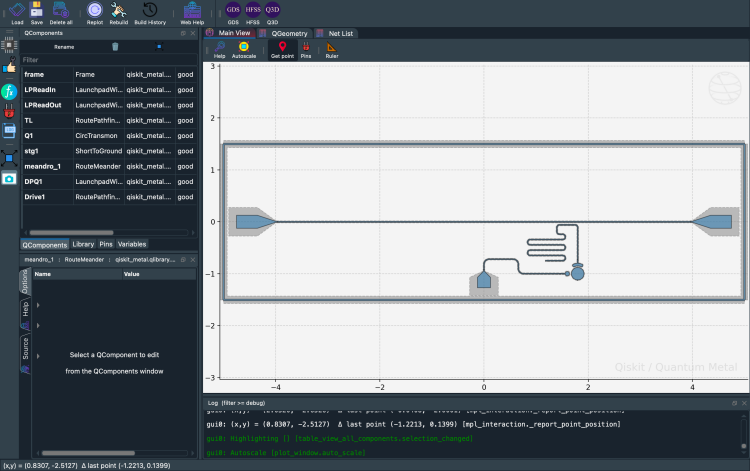

In [69]:
gui.autoscale()
gui.screenshot()

## Simulación del Resonador

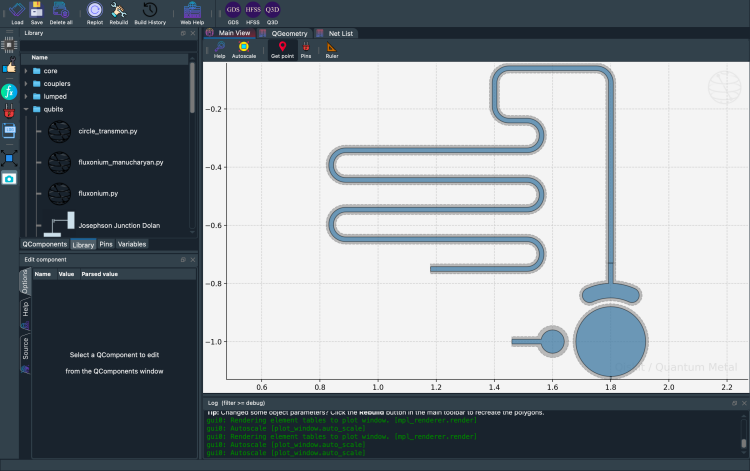

In [6]:
gui.autoscale()
gui.screenshot()

In [7]:
# Directories and file paths.
device_name = "example_transmon"
# Work in the outputs folder of the current directory.
output_dir = str(Path.cwd() / "output" / device_name)
# Geometry XAO file required for adaptive meshing.
geo_filepath = output_dir + "/" + device_name + ".xao"
# Mesh file.
mesh_filepath = output_dir + "/" + device_name + ".msh4"

# Whether to calculate the capacitance matrix using adaptive meshing.
adaptive = True
# Set minimum and maximum characteristic lengths for the mesh elements.
mesh_h_min = "150um"
mesh_h_max = "300um"
# Number of Maxwell eigenmodes.
num_modes = 1

# Setting up the solver
qtcad_renderer = QQTCADRenderer(
    design,
    options=dict(
        adaptive=adaptive,
        output_dir=output_dir,
        mesh_scale=1e-3,
        adaptive_mesh_scale=1e-3,
        geo_filepath=geo_filepath,
        mesh_filepath=mesh_filepath,
        make_subdir=False,
        box_plus_buffer=True,        # Usar bbox del diseño + buffer
        buffer_distance='300um',
        maxwell_emode=dict(
            num_modes=num_modes,
            tol_rel=0.1,
        ),
    ),
)

open_pins = [("Q1", "claw_a")]

# Create the geometry from the design.
qtcad_renderer.render_design(
    selection=['stg1','Q1','meandro_1'],
    open_pins=open_pins,
    # Do not mesh the device (yet).
    mesh_geoms=False,
    initial_mesh_h_min=mesh_h_min,
    initial_mesh_h_max=mesh_h_max,
)

Info    : Clearing all models and views...
Info    : Done clearing all models and views


In [8]:
# Mesh the device.
qtcad_renderer.gmsh.add_mesh(dim=3, intelli_mesh=adaptive)
# Export the geometry and mesh files.
file_mesh, file_geo = qtcad_renderer.export_mesh()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 3523 (Line)
Info    : [ 10%] Meshing curve 3524 (Line)
Info    : [ 10%] Meshing curve 3525 (Line)
Info    : [ 10%] Meshing curve 3526 (Line)
Info    : [ 10%] Meshing curve 3527 (Line)
Info    : [ 10%] Meshing curve 3528 (Line)
Info    : [ 10%] Meshing curve 3529 (Line)
Info    : [ 10%] Meshing curve 3530 (Line)
Info    : [ 10%] Meshing curve 3531 (Line)
Info    : [ 10%] Meshing curve 3532 (Line)
Info    : [ 10%] Meshing curve 3533 (Line)
Info    : [ 10%] Meshing curve 3534 (Line)
Info    : [ 10%] Meshing curve 3535 (Line)
Info    : [ 10%] Meshing curve 3536 (Line)
Info    : [ 10%] Meshing curve 3537 (Line)
Info    : [ 10%] Meshing curve 3538 (Line)
Info    : [ 10%] Meshing curve 3539 (Line)
Info    : [ 10%] Meshing curve 3540 (Line)
Info    : [ 10%] Meshing curve 3541 (Line)
Info    : [ 10%] Meshing curve 3542 (Line)
Info    : [ 10%] Meshing curve 3543 (Line)
Info    : [ 10%] Meshing curve 3544 (Line)
Info    : [ 10%] Meshing curve

11:59AM 20s WARNING [export_geometry]: WARNING: The existing model contains mesh size field definitions, which are not needed when exporting to XAO files for use in renderers that support adaptive meshing refinement (AMR). If you are going to use AMR, consider disabling the use of mesh size fields.


Info    :  	Final tet. mesh contains 28953 tetrahedra
Info    :  	Final tet. mesh contains 5697 vertices
Info    : tEmptyMesh  	 = 	    0.021
Info    : tVerifyBnd  	 = 	    0.002
Info    : tBndRecovery	 = 	    0.031
Info    : tConvertMesh	 = 	    0.002
Info    : tRefine     	 = 	    0.271
Info    : tOptimize   	 = 	   42.990
Info    : Done meshing 3D (Wall 43.3366s, CPU 43.1801s)
Info    : 5723 nodes 50881 elements
Info    : Writing '/Users/leubiedo/Documents/QuantumCircuits/tutorials/output/example_transmon/example_transmon.xao'...
Info    : Done writing '/Users/leubiedo/Documents/QuantumCircuits/tutorials/output/example_transmon/example_transmon.xao'
Info    : Writing '/Users/leubiedo/Documents/QuantumCircuits/tutorials/output/example_transmon/example_transmon.msh4'...
Info    : Done writing '/Users/leubiedo/Documents/QuantumCircuits/tutorials/output/example_transmon/example_transmon.msh4'


In [11]:
import os
os.environ["QTCAD_LICENSE_PATH"] = "/Users/leubiedo/Downloads/license-3.lic"
# Export parameters.
qtcad_renderer.export_parameters()
# Run QTCAD to extract the Maxwell eigenmodes.
qtcad_renderer.run_qtcad("eigs",env_name="qtcad-2.2.2")

12:10PM 38s INFO [run_qtcad]: =================
12:10PM 38s INFO [run_qtcad]: Running QTCAD®...
12:10PM 38s INFO [run_qtcad]: =================


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   
                                 Version 2.2.2                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   
      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      
                        For documentation, please visit:                        
                      https://doc

In [12]:
frequencies = qtcad_renderer.load_qtcad_maxwell_eigenmodes()
print(frequencies)

           Frequency (GHz)
Eigenmode                 
0                 5.868866


2026-08-06 12:21:22.787 (1506.256s) [          19A072]vtkOpenGLRenderWindow.c:876   WARN| vtkCocoaRenderWindow (0x3212efa80): Failed to get red color buffer size (1280)
2026-08-06 12:21:22.788 (1506.256s) [          19A072]vtkOpenGLRenderWindow.c:886   WARN| vtkCocoaRenderWindow (0x3212efa80): Failed to get green color buffer size (1280)
2026-08-06 12:21:22.788 (1506.256s) [          19A072]vtkOpenGLRenderWindow.c:896   WARN| vtkCocoaRenderWindow (0x3212efa80): Failed to get blue color buffer size (1280)
2026-08-06 12:21:22.788 (1506.256s) [          19A072]vtkOpenGLRenderWindow.c:906   WARN| vtkCocoaRenderWindow (0x3212efa80): Failed to get alpha color buffer size (1280)


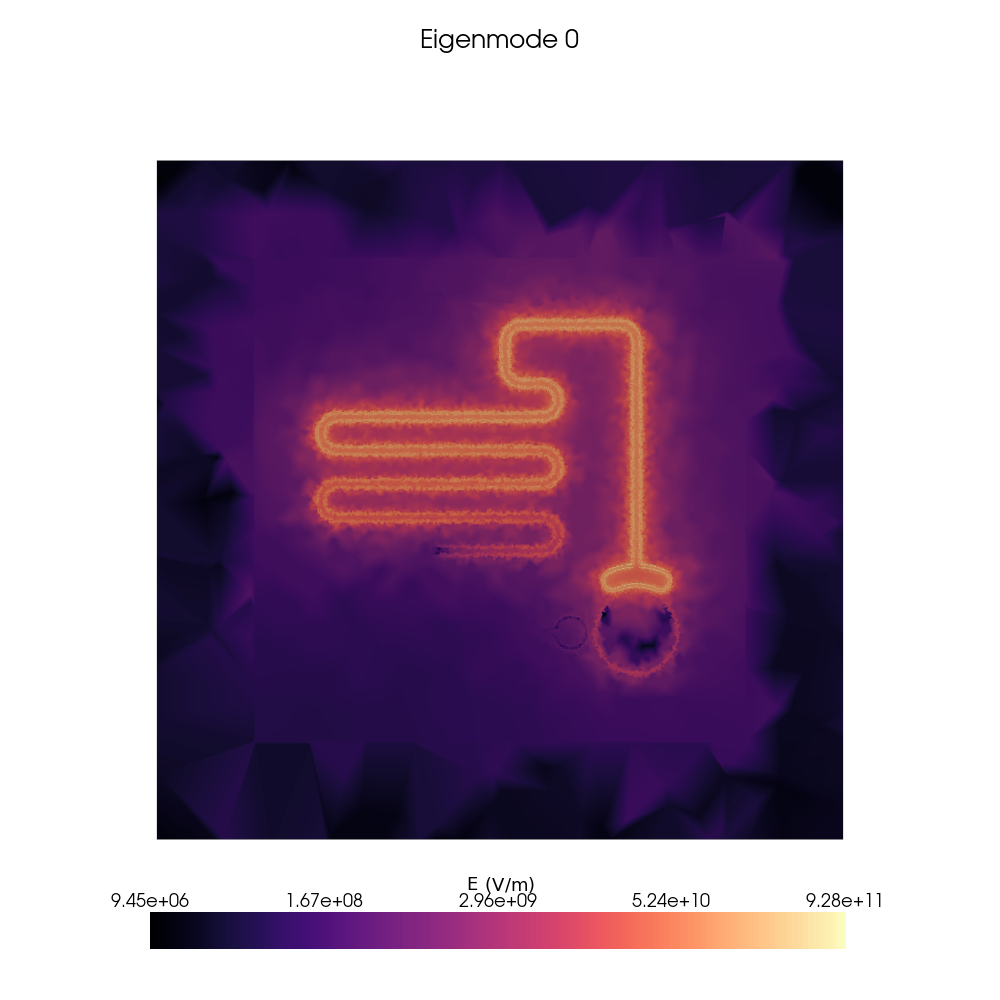

In [16]:
#qtcad_renderer.plot_eigenmodes(save=True)

import pyvista as pv

vtu = "output/example_transmon/qtcad-fields.vtu"   # tu archivo de campos
array = "abs(electric field) [V/m]"                # nombre real en 2.2.2

reader = pv.get_reader(vtu)
reader.disable_all_point_arrays()
reader.enable_point_array(array)
mesh = reader.read()

# corte en z=0 (plano del metal) — igual que hace plot_eigenmode
sliced = mesh.slice(normal="z", origin=(0, 0, 0))

p = pv.Plotter(window_size=(1000, 1000))
p.add_mesh(sliced, scalars=array, log_scale=True, cmap="magma", show_scalar_bar=False)
p.add_scalar_bar(title="|E| (V/m)", position_x=0.15, position_y=0.05, width=0.7, height=0.1)
p.add_title("Eigenmode 0", font_size=11)
p.view_xy()
p.show()